# Density -> consumption, a proof of concept (prospection)

Today's code (`urban_scenario.nodes`): income sets the demand LEVEL (`income_factor`),
density only reshapes the building-template MIX (`unit_share_by_density`) --
`total_units` is pinned by income alone. This tests one proposed extra term: a
node's `total_units` (and hence volume) also scaled by a `multiplier` when its
density category changes, holding income fixed -- i.e. a family-of-4 house becoming
a ~50-person medium building should increase consumption, not just reshuffle it.

Four tiers, each cheaper than the next:
1. per-unit invariance -- does the multiplier keep m3/household honest?
2. calibration / plausibility -- how far can it go before `[0.5, 2.0]` or
   building counts stop being believable?
3. compounding -- today's code vs proposed, side by side, same node
4. real EPANET pressure -- the actual hydraulic consequence, via the repo's own
   `run_hydraulics` + V1-V3, fed a level-rescaled demand series (tier 4 is the
   only one that runs a real simulation -- it's slow, one EPANET run per
   multiplier).

Reads real catalog artifacts for the `local` world (`portfolios_t0`,
`income_factors`, `wn_variant`, `demand_series`) -- nothing recomputed from
scratch, no repo file modified. Run from `notebooks/prospection/`, `density_poc.py`
alongside this notebook.

## 0. Setup

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR))


def find_repo_root(start: Path | None = None) -> Path | None:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "conf" / "base" / "parameters.yml").exists() and (cand / "src" / "fedwater").is_dir():
            return cand
    return None


ROOT = find_repo_root()
if ROOT is None:
    raise RuntimeError("fedwater repo root not found -- put this notebook in <repo>/notebooks/prospection/.")
sys.path.insert(0, str(ROOT / "src"))

import density_poc as D  # the engine -- data loading + formulas + hydraulics wrapper

mpl.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
print("repo:", ROOT)

repo: C:\Users\arthu\USPy\10_Mestrado\experiments\fedWater


## 1. Load real artifacts (`local` world)

`portfolios_t0` and `income_factors` already carry today's real, computed values --
nothing here is a re-derivation. `wn_variant` + `demand_series` are the actual
network object and demand series the last `local` run produced.

In [2]:
ART = D.load_local_artifacts(ROOT)
mean_unit = D.mean_unit_lookup(ART["income_factors"])
print("mean_unit_m3_month:", mean_unit)
ART["income_factors"]

mean_unit_m3_month: {'low': 9.25, 'medium': 13.5, 'high': 29.0}


,income,mean_unit_m3_month,income_factor
0,low,9.25,0.685185
1,medium,13.50,1.000000
2,high,29.00,2.148148


## 2. Config -- target node and the multiplier grid

Default target is the scenario's own drift seed node (`scenario.drift.seed_node`,
District_D) -- but note the *shipped* drift for that node is `to_density: low`
(no density change at all); `to_density` here is set to `medium` deliberately, to
actually exercise a density transition the shipped scenario doesn't.

In [3]:
CONFIG = {
    "node": "2",
    "to_density": "medium",
    "multipliers": [1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0],
    "seed": 0,
}
BASE = D.node_baseline(ART["portfolios_t0"], CONFIG["node"])
print("baseline:", BASE)

baseline: {'node': '2', 'income': 'low', 'density': 'low', 'anchor_m3_month': 4412.88, 'calibration': 1.4594594594594594, 'volume_m3_month': 4412.88, 'total_units': 477.06810810810816}


## 3. Tier 1 -- per-unit invariance

`volume_m3_month / total_units` should equal `mean_unit_m3_month[income]` at every
multiplier, by construction -- this is the direct check on "does this inflate
consumption per household" (expected: no, since `mean_unit` never enters the
density side of the formula).

In [4]:
rows = []
for m in CONFIG["multipliers"]:
    v = D.density_variant(BASE, ART["buildings"], mean_unit, CONFIG["to_density"], m, seed=CONFIG["seed"])
    rows.append(dict(multiplier=m, total_units=v["total_units"],
                     volume_m3_month=v["volume_m3_month"], per_unit_m3_month=v["per_unit_m3_month"]))
tier1 = pd.DataFrame(rows)
tier1["invariant"] = np.isclose(tier1["per_unit_m3_month"], mean_unit[BASE["income"]])
tier1

,multiplier,total_units,volume_m3_month,per_unit_m3_month,invariant
0,1.0,477.068108,4412.88,9.25,True
1,1.5,715.602162,6619.32,9.25,True
2,2.0,954.136216,8825.76,9.25,True
3,3.0,1431.204324,13238.64,9.25,True
4,5.0,2385.340541,22064.40,9.25,True
5,8.0,3816.544865,35303.04,9.25,True
6,12.0,5724.817297,52954.56,9.25,True


## 4. Tier 2 -- calibration and building-count plausibility

Network-wide `calib = sum(anchor) / sum(volume)` (the same ratio `build_portfolios`
checks once, at t0) if this ONE node's volume were replaced per `multiplier`,
everything else held at today's values -- finds where `[0.5, 2.0]` breaks.
`n_buildings` per template is alongside for an eyeball plausibility check (no
ground truth for "too many buildings", so this is a read, not a pass/fail).

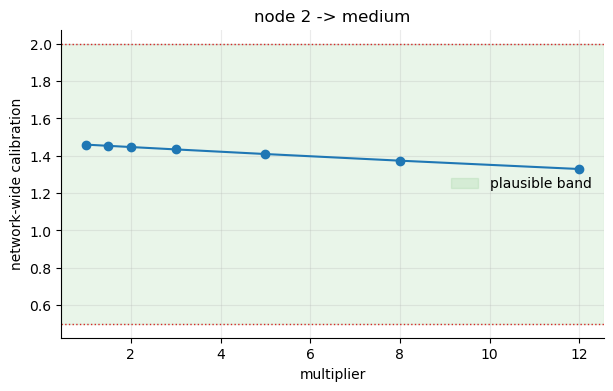

,multiplier,node_volume_m3_month,network_calibration,inside_bounds
0,1.0,4412.88,1.459459,True
1,1.5,6619.32,1.452963,True
2,2.0,8825.76,1.446524,True
3,3.0,13238.64,1.433815,True
4,5.0,22064.40,1.409057,True
5,8.0,35303.04,1.373481,True
6,12.0,52954.56,1.328751,True


In [5]:
tier2 = D.calibration_sweep(ART["portfolios_t0"], BASE, mean_unit, ART["buildings"],
                            CONFIG["to_density"], CONFIG["multipliers"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tier2["multiplier"], tier2["network_calibration"], "o-")
ax.axhspan(0.5, 2.0, color="tab:green", alpha=0.1, label="plausible band")
ax.axhline(0.5, color="tab:red", ls=":", lw=1)
ax.axhline(2.0, color="tab:red", ls=":", lw=1)
ax.set(xlabel="multiplier", ylabel="network-wide calibration", title=f"node {CONFIG['node']} -> {CONFIG['to_density']}")
ax.legend(frameon=False)
plt.show()
tier2

In [6]:
plaus = D.plausibility_table(BASE, ART["buildings"], mean_unit, CONFIG["to_density"], CONFIG["multipliers"])
plaus.pivot_table(index="template", columns="multiplier", values="n_buildings")

multiplier,1.0,1.5,2.0,3.0,5.0,8.0,12.0
template,,,,,,,
buildings_M,3.0,4.0,5.0,8.0,13.0,21.0,32.0
buildings_P,23.0,34.0,45.0,68.0,113.0,181.0,272.0
houses,67.0,101.0,134.0,202.0,336.0,538.0,807.0


## 5. Tier 3 -- compounding, today's code vs proposed

`multiplier=1.0` in Tier 1/2's own sweep already IS today's actual code output for
this density transition (income-only `total_units`, re-split by the new density's
mix) -- no separate recomputation needed, just read that row against any other.

In [7]:
compare = tier1.copy()
compare["vs_today_volume_ratio"] = compare["volume_m3_month"] / tier1.loc[tier1["multiplier"] == 1.0, "volume_m3_month"].iloc[0]
compare[["multiplier", "total_units", "volume_m3_month", "vs_today_volume_ratio"]]

,multiplier,total_units,volume_m3_month,vs_today_volume_ratio
0,1.0,477.068108,4412.88,1.0
1,1.5,715.602162,6619.32,1.5
2,2.0,954.136216,8825.76,2.0
3,3.0,1431.204324,13238.64,3.0
4,5.0,2385.340541,22064.40,5.0
5,8.0,3816.544865,35303.04,8.0
6,12.0,5724.817297,52954.56,12.0


## 6. Tier 4 -- real EPANET pressure sweep

The actual hydraulic consequence: `demand_series` for this node scaled by
`multiplier` (shape held fixed -- a level-only approximation; a full
implementation would also let the extra units feed `synthesize_demands`'s
crowd-smoothing law, shifting the shape a little too), then the repo's own
`run_hydraulics` + V1-V3, one full simulation per multiplier. Slow.

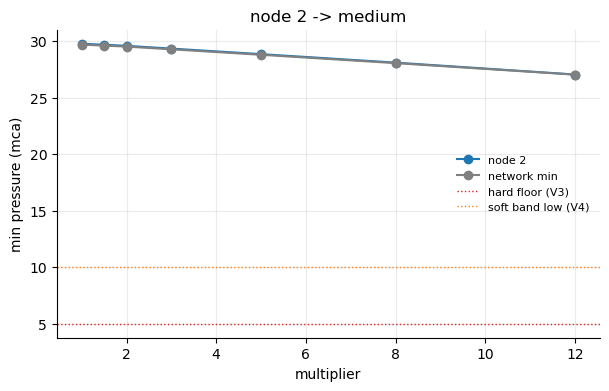

,multiplier,min_pressure_node,min_pressure_network,v1_v3_error
0,1.0,29.774984,29.696611,None
1,1.5,29.685049,29.608175,None
2,2.0,29.587376,29.519526,None
3,3.0,29.343634,29.280846,None
4,5.0,28.852510,28.796190,None
5,8.0,28.102398,28.057890,None
6,12.0,27.050056,27.039001,None


In [8]:
tier4 = D.pressure_sweep(ART["wn"], ART["demand_series"], CONFIG["node"],
                         CONFIG["multipliers"], ART["validation"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tier4["multiplier"], tier4["min_pressure_node"], "o-", label=f"node {CONFIG['node']}")
ax.plot(tier4["multiplier"], tier4["min_pressure_network"], "o-", color="0.5", label="network min")
ax.axhline(ART["validation"]["hard_pressure_floor_mca"], color="tab:red", ls=":", lw=1, label="hard floor (V3)")
ax.axhline(ART["validation"]["pressure_band_mca"][0], color="tab:orange", ls=":", lw=1, label="soft band low (V4)")
ax.set(xlabel="multiplier", ylabel="min pressure (mca)", title=f"node {CONFIG['node']} -> {CONFIG['to_density']}")
ax.legend(frameon=False, fontsize=8)
plt.show()
tier4

## 7. Wrap

In [9]:
calib_ok = tier2[tier2["inside_bounds"]]["multiplier"].max()
v3_ok = tier4[tier4["v1_v3_error"].isna()]["multiplier"].max()
print(f"node {CONFIG['node']} ({BASE['income']}, {BASE['density']} -> {CONFIG['to_density']}):")
print(f"  calibration stays inside [0.5, 2.0] up to multiplier = {calib_ok}")
print(f"  V1-V3 (real EPANET) hold up to multiplier = {v3_ok}")
print(f"  per-unit consumption invariant at every multiplier tested: {bool(tier1['invariant'].all())}")

node 2 (low, low -> medium):
  calibration stays inside [0.5, 2.0] up to multiplier = 12.0
  V1-V3 (real EPANET) hold up to multiplier = 12.0
  per-unit consumption invariant at every multiplier tested: True


In [10]:
def stress_variant(portfolios_t0, income_factors, node_ids, mode,
                   density_multiplier=1.0, target_income="high"):
    """New volume_m3_month for `node_ids` under one of three stress modes
    ('income', 'density', 'both'), everything else held at today's real
    values. 'density' applies the proposed density_factor extension as a
    flat multiplier (no settled per-tier table yet); 'income' uses the
    real income_factor lookup already in the catalog."""
    factor = dict(zip(income_factors["income"], income_factors["income_factor"]))
    per_node = portfolios_t0.drop_duplicates("node").set_index("node")
    vol = per_node["volume_m3_month"].copy()
    sel = per_node.index.isin(node_ids)
    anchor, calib = per_node["anchor_m3_month"], per_node["calibration"]
    income = per_node["income"].copy()
    if mode in ("income", "both"):
        income.loc[sel] = target_income
    mult = pd.Series(1.0, index=per_node.index)
    if mode in ("density", "both"):
        mult.loc[sel] = density_multiplier
    vol.loc[sel] = anchor.loc[sel] * calib.loc[sel] * income.loc[sel].map(factor) * mult.loc[sel]
    return vol


def network_calibration(portfolios_t0, volume_override: pd.Series) -> float:
    per_node = portfolios_t0.drop_duplicates("node").set_index("node")
    return per_node["anchor_m3_month"].sum() / volume_override.reindex(per_node.index).sum()


def max_nodes_before_break(portfolios_t0, income_factors, district_nodes, mode,
                           density_multiplier=1.0, order="worst") -> int:
    """Binary search: how many of `district_nodes` can be pushed to the
    stress state before network-wide calibration exits [0.5, 2.0].
    order='worst' pushes highest-anchor nodes first (a lower bound on the
    achievable count); order='best' pushes lowest-anchor nodes first (an
    upper bound) -- report both, since WHICH nodes matters, not just how many."""
    per_node = portfolios_t0.drop_duplicates("node").set_index("node")
    ranked = per_node.loc[district_nodes, "anchor_m3_month"].sort_values(ascending=(order == "best"))
    ordered = ranked.index.tolist()
    lo, hi = 0, len(ordered)
    while lo < hi:
        mid = (lo + hi + 1) // 2
        vol = stress_variant(portfolios_t0, income_factors, ordered[:mid], mode, density_multiplier)
        if 0.5 <= network_calibration(portfolios_t0, vol) <= 2.0:
            lo = mid
        else:
            hi = mid - 1
    return lo


# sweep: mode x order, per district alone + all districts combined
districts = {d: g["node"].tolist() for d, g in ART["portfolios_t0"].groupby("district")}
rows = []
for mode in ("income", "density", "both"):
    for order in ("worst", "best"):
        for d, nodes in districts.items():
            n = max_nodes_before_break(ART["portfolios_t0"], ART["income_factors"], nodes, mode,
                                       density_multiplier=12.0, order=order)
            rows.append(dict(mode=mode, order=order, district=d, max_nodes=n, total_nodes=len(nodes)))
        all_nodes = ART["portfolios_t0"]["node"].tolist()
        n_all = max_nodes_before_break(ART["portfolios_t0"], ART["income_factors"], all_nodes, mode,
                                       density_multiplier=12.0, order=order)
        rows.append(dict(mode=mode, order=order, district="ALL_COMBINED", max_nodes=n_all, total_nodes=len(all_nodes)))
stress_report = pd.DataFrame(rows)
stress_report.pivot_table(index=["mode", "district"], columns="order", values="max_nodes")

order                  best  worst
mode    district                  
both    ALL_COMBINED   27.0    0.0
        District_A     21.0    6.0
        District_B     15.0    3.0
        District_C     21.0    6.0
        District_D     18.0    0.0
        District_E     18.0    3.0
density ALL_COMBINED   72.0    9.0
        District_A     33.0   33.0
        District_B     39.0   12.0
        District_C     48.0   33.0
        District_D     48.0    9.0
        District_E     45.0   18.0
income  ALL_COMBINED  231.0   84.0
        District_A     33.0   33.0
        District_B     87.0   87.0
        District_C     54.0   54.0
        District_D     72.0   72.0
        District_E     90.0   90.0

In [11]:
from itertools import combinations

_LETTER = {"L": "low", "M": "medium", "H": "high"}

def decode_consumption_map(code: str) -> list[list[str]]:
    """'LH_LL_LL_LL_LL' -> [[income, density], ...] in district order."""
    return [[_LETTER[p[0]], _LETTER[p[1]]] for p in code.split("_")]


def _stressed_background(pattern: str) -> str:
    """The 'more stressful' background for a pattern like 'LH'/'HL' -- bump
    the SAME axis the pattern itself stresses from 'L' to 'M':
    'LH' (density-stressed) -> 'LM', 'HL' (income-stressed) -> 'ML'."""
    chars = list(pattern)
    for i, c in enumerate(chars):
        if c != "L":
            chars[i] = "M"
            break
    return "".join(chars)


def generate_combos(pattern: str, district_names: list[str], k_values=(1, 2, 3),
                    background_codes: list[str] | None = None) -> list[str]:
    """For each k in k_values, every way to set k districts to `pattern`
    (e.g. 'LH' or 'HL'), the rest held at each of `background_codes` in turn.
    Defaults to ['LL', <pattern's own axis bumped to M>] -- e.g. 'LH' gives
    ['LL', 'LM'], 'HL' gives ['LL', 'ML']: a plain baseline plus a more-
    stressful background on the same axis the pattern is testing. Pass
    `background_codes` explicitly to use something else (e.g. ['LL', 'MM'])."""
    if background_codes is None:
        background_codes = ["LL", _stressed_background(pattern)]
    seen, codes = set(), []
    for bg in background_codes:
        for k in k_values:
            for combo in combinations(range(len(district_names)), k):
                parts = [bg] * len(district_names)
                for i in combo:
                    parts[i] = pattern
                code = "_".join(parts)
                if code not in seen:  # k == len(district_names): background is
                    seen.add(code)    # irrelevant, every position gets overwritten
                    codes.append(code)
    return codes


def build_static_world(wn, districts, income_factors, buildings, hydraulics,
                       patterns, time, consumption_map: str, seed: int = 0):
    """One consumption_map, no drift, worst-case (peak) month only -- the
    real build_portfolios + real synthesize_demands, end to end.
    `build_portfolios` itself raises ValueError if the t0 calibration bound
    [0.5, 2.0] already fails -- caught by the caller, not here."""
    from fedwater.pipelines.urban_scenario.nodes import build_portfolios
    from fedwater.pipelines.demand_synthesis.nodes import synthesize_demands

    mapping = decode_consumption_map(consumption_map)
    scenario = {"income_density_mapping": mapping}
    portfolios_t0 = build_portfolios(wn, districts, income_factors, scenario,
                                     buildings, hydraulics, seed)

    timeline = portfolios_t0.copy()
    timeline["month"] = 0
    patterns_peak = {**patterns, "seasonal_peak_month": 0}  # force the single test
    time_short = {**time, "n_months": 6}                    # month == the seasonal peak
    demand_series = synthesize_demands(timeline, patterns_peak, time_short, seed)
    return portfolios_t0, demand_series, time_short


def run_combo(wn, districts, income_factors, buildings, hydraulics, patterns,
             time, validation, consumption_map: str, seed: int = 0) -> dict:
    """Full stack for one consumption_map: build_portfolios -> synthesize_demands
    -> real run_hydraulics -> real V1-V3 (via density_poc.run_v1_v3, already
    imported as D). Any stage's own exception is caught and recorded as the
    failure reason -- nothing propagates, the sweep never dies mid-run."""
    from fedwater.pipelines.network_prep.nodes import configure_network
    try:
        portfolios_t0, demand_series, time_short = build_static_world(
            wn, districts, income_factors, buildings, hydraulics, patterns, time,
            consumption_map, seed)
    except ValueError as e:
        return dict(consumption_map=consumption_map, stage="portfolio_calibration",
                   feasible=False, error=str(e), min_pressure=np.nan)
    
    wn_short = configure_network(wn, hydraulics, time_short)
    out = D.run_v1_v3(wn_short, demand_series, validation)
    node_cols = [c for c in demand_series.columns if c != "month"]
    min_p = float(out["pressures"][node_cols].to_numpy().min())
    max_p = float(out["pressures"][node_cols].to_numpy().max())
    return dict(consumption_map=consumption_map, stage="hydraulics",
               feasible=out["error"] is None, error=out["error"], min_pressure=min_p, max_pressure = max_p)


# --- run it -------------------------------------------------------------
district_names = list(ART["districts"]["districts"])
combos = (generate_combos("LH", district_names, k_values=(1, 2, 3, 4, 5))
          + generate_combos("LM", district_names, k_values=(1, 2, 3, 4, 5))
          + generate_combos("ML", district_names, k_values=(1, 2, 3, 4, 5))
         + generate_combos("HL", district_names, k_values=(1, 2, 3, 4, 5)))

# results = [run_combo(ART["wn"], ART["districts"], ART["income_factors"], ART["buildings"],
#                      ART["hydraulics"], ART["patterns"], ART["time"], ART["validation"], cm)
#           for cm in combos]
# stress_report = pd.DataFrame(results)
# infeasible = stress_report[~stress_report["feasible"]]
# stress_report.sort_values("min_pressure")

In [12]:
import density_poc as D, density_sweep as S
from fedwater.pipelines.urban_scenario.nodes import build_income_factors

ART = D.load_local_artifacts(ROOT)
ART["income_factors"] = build_income_factors(ART["buildings"])

DISTRICT_NAMES = list(ART["districts"]["districts"])
per_node = ART["portfolios_t0"].drop_duplicates("node")

# what the world was ACTUALLY built from (an experiments-engine world can
# override the shipped map via consumption_map), not the parameters.yml default
mapping_actual = (per_node.groupby("district")[["income", "density"]].first()
                  .reindex(DISTRICT_NAMES).values.tolist())

aw = (per_node.groupby("district")["anchor_m3_month"].sum()
      .reindex(DISTRICT_NAMES))

dfac = S.build_density_factors(ART["buildings"], normalize="reference_map",
                               reference_map=mapping_actual, anchor_weights=aw)

# cases = S.background_cases(DISTRICT_NAMES)          # k = 3, 4, 5 by default
# report = S.sweep_background_feasibility(ART, dfac, cases, bisect=False)

cases = S.background_cases(DISTRICT_NAMES, single_step_density=True)   # 47, drops LH/LL
alpha_report = S.sweep_alpha(ART, cases, alphas=(0.0, 0.25, 0.5, 0.75, 1.0),
                             reference_map=mapping_actual, anchor_weights=aw)

alpha_report.groupby(["alpha", "density_swing"])["v3_passes_today"].agg(["sum", "count"])

,,sum,count
alpha,density_swing,,
0.00,1.000000,16,47
0.25,1.504775,16,47
0.50,2.264348,16,47
0.75,3.407335,16,47
1.00,5.127273,14,47


In [13]:
alpha_report[~alpha_report['v3_passes_today']].shape

(157, 16)

In [14]:
alpha_report.shape

(235, 16)

In [15]:
print(ART["buildings"]["standards_by_income"])
print(ART["buildings"]["unit_m3_month"])
print(ART["income_factors"])   # already computed: mean_unit_m3_month, income_factor per tier

print(ART["buildings"]["unit_share_by_density"])
print(ART["buildings"]["units_per_building"])
print(S.mean_units_per_building(ART["buildings"]))   # derived E[units/building] per density

{'low': {1: 0.75, 2: 0.15, 3: 0.1}, 'medium': {1: 0.25, 2: 0.25, 3: 0.5}, 'high': {3: 0.15, 4: 0.4, 5: 0.45}}
{1: 1, 2: 2, 3: 4, 4: 6, 5: 9}
   income  mean_unit_m3_month  income_factor
0     low                1.45       0.527273
1  medium                2.75       1.000000
2    high                7.05       2.563636
{'low': {'houses': 0.85, 'buildings_P': 0.15}, 'medium': {'houses': 0.5, 'buildings_P': 0.4, 'buildings_M': 0.1}, 'high': {'houses': 0.2, 'buildings_P': 0.3, 'buildings_M': 0.4, 'buildings_G': 0.1}}
{'houses': [1, 5], 'buildings_P': [6, 15], 'buildings_M': [17, 40], 'buildings_G': [45, 75]}
{'low': 4.125, 'medium': 8.55, 'high': 21.15}


In [18]:
alpha_report.groupby(["alpha", "pattern"])["v3_passes_today"].agg(["sum", "count"])

sum  count
alpha pattern            
0.00  HL         0     31
      LH        16     16
0.25  HL         0     31
      LH        16     16
0.50  HL         0     31
      LH        16     16
0.75  HL         0     31
      LH        16     16
1.00  HL         0     31
      LH        14     16